In [1]:
import os
cwd = os.getcwd()
cwd

'C:\\Users\\mag356\\Desktop\\DDM'

   pertSize  reactionTime  initialResponse  subID  blockNo  speed  \
0       100      1.718003               -1      1        1      0   
1        25      1.961003               -1      1        1      0   
2       -50      2.397006                1      1        1      0   
3      -200      3.371999                1      1        1      0   
4       150      2.364999               -1      1        1      0   

   leftResponse  rightResponse  noResponse  
0             1              0           0  
1             1              0           0  
2             0              1           0  
3             0              1           0  
4             1              0           0  


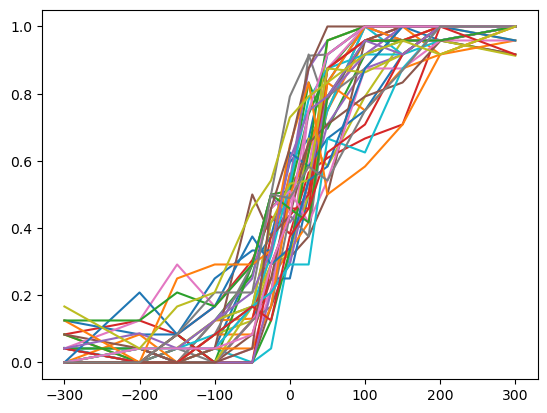

<Figure size 640x480 with 0 Axes>

In [2]:
#Load data in detailed form by running load_data.py script
from utils import *
data = load_data()

# DDM fitting to reaction times (RTs)

## Model fitting

In [3]:
#Change this variable depending if you want to fit against raw perturbation size ('pertSize') or perturbation size normalized by mean walking speed ('WF')
stimuli = 'pertSize'

#Use reaction times to fit DDM parameters
n_subs = data['subID'].nunique()
jnd_RT = []
pse_RT = []
#Generate structure to save parameter estimates
params_RT = np.zeros((n_subs * 2, 4))
params_Acc = np.zeros((n_subs * 2, 3))
logL_RT = np.zeros(n_subs * 2)
logL_Acc = np.zeros(n_subs * 2)
#Create a new dataframe supressing noResponse trials
df_excludingNR = data[data['noResponse'] == 0].copy()
# Create absolute pertSize column
df_excludingNR["abs_pertSize"] = np.abs(df_excludingNR["pertSize"])
speed_map = {0: 1050, 1: 700, 2: 1400, 3: 1750}

row_i = 0
for sub in df_excludingNR['subID'].unique():
    if sub<14: # Comfortable speed group 
        speed = [0,2]
    elif sub>13 and sub<27:
        speed = [0,1]
    elif sub>26:
        speed = [0,3]
   
    for sp in speed:
        t = df_excludingNR[(df_excludingNR['subID'] == sub) & (df_excludingNR['speed'] == sp)].groupby([stimuli])['reactionTime'].mean()
        ch = df_excludingNR[(df_excludingNR['subID'] == sub) & (df_excludingNR['speed'] == sp)]['leftResponse'].values
        dv2 = df_excludingNR[(df_excludingNR['subID'] == sub) & (df_excludingNR['speed'] == sp)][stimuli].values
        dv = t.index.to_numpy()
        t = t.values
        n_reps = df_excludingNR[(df_excludingNR['subID'] == sub) & (df_excludingNR['speed'] == sp)].groupby([stimuli,'speed'])['reactionTime'].count() #Counting repetitions
        t_nd, noise_std, a, b = fit_RT(t, dv, bounds = ((-3,3), (0.001, 1), (-1e-10, 1e-10), (-250, -0.01))) #Fit mean RT data, forcing the PSE to be close to zero, we allow the non-decision time to be negative since we have RT to be from the cue, not stim onset
        #Fit acc data for viz purposes        
        a_acc, b_acc,c_acc = fit_params(ch, dv2, bounds = ((-50, 50), (-200, -.001), (0,0))) #No DR fitting
    
        #Print results
        k = np.log(3)
        print("Subject: ", sub, ", Speed: ", sp)
        print("t_nd: ", t_nd)
        print("Noise: ", noise_std)
        print("PSE: ", a)
        print("JND: ", -b*k)        
        logL_RT[row_i] = neg_log_likelihood((a, b, 0), ch, dv2, nreps=1)
        print("\n")
        #Save results
        jnd_RT.append(np.abs(-b*k))
        pse_RT.append(a)
        params_RT[row_i, :] = [t_nd, noise_std, a, b]    
        params_Acc[row_i,:] = [a_acc, b_acc, 0]
        logL_Acc[row_i] = neg_log_likelihood((a_acc, b_acc, 0), ch, dv2, nreps=1)
        row_i += 1

#Print results
print("----RT results----")
print("JND: ", np.mean(jnd_RT))
print("PSE: ", np.mean(pse_RT))
print("Cum logL: ", np.sum(-logL_RT))
print("---ACC results----")
print("JND: ", -1*np.mean(params_Acc[:,1]*k))
print("PSE: ", np.mean(params_Acc[:,0]))
print("Cum logL: ", np.sum(-logL_Acc))


# Change the data formatting to match the one in Matlab to be able to generate Figure 3 and save is as a csv file

group1_df = pd.DataFrame({"Reference": pd.Series(dtype='float'), "Testing": pd.Series(dtype='float')})
group2_df = pd.DataFrame({"Reference": pd.Series(dtype='float'), "Testing": pd.Series(dtype='float')})
group3_df = pd.DataFrame({"Reference": pd.Series(dtype='float'), "Testing": pd.Series(dtype='float')})

# Loop over your jnd_RT list and fill the data Frame based on the subject ID:

n_subs = len(jnd_RT) // 2  # there are 2 speeds per subject

for i in range(n_subs):
    sub_id = i  
    ref_jnd = jnd_RT[2 * i]
    test_jnd = jnd_RT[2 * i + 1]

    new_row = {"Reference": ref_jnd, "Testing": test_jnd}

    if sub_id < 13:
        group2_df = pd.concat([group2_df, pd.DataFrame([new_row])], ignore_index=True)
    elif sub_id < 26:
        group1_df = pd.concat([group1_df, pd.DataFrame([new_row])], ignore_index=True)
    else:
        group3_df = pd.concat([group3_df, pd.DataFrame([new_row])], ignore_index=True)

# # Save each DataFrame separately as CSV:
# folder_path = cwd + r"\Outputs"
# os.makedirs(folder_path, exist_ok=True)
# group1_df.to_csv(f"{folder_path}/group1_JND_{stimuli}.csv", index=False)
# group2_df.to_csv(f"{folder_path}/group2_JND_{stimuli}.csv", index=False)
# group3_df.to_csv(f"{folder_path}/group3_JND_{stimuli}.csv", index=False)


Subject:  1 , Speed:  0
t_nd:  0.3652515432049425
Noise:  0.46874602128244514
PSE:  -9.999999999999999e-11
JND:  22.696023383948653


Subject:  1 , Speed:  2
t_nd:  0.0743310661681746
Noise:  0.44624888186378053
PSE:  9.999999999999999e-11
JND:  21.154805122308762


Subject:  2 , Speed:  0
t_nd:  2.0704404943279138
Noise:  0.4593588712363383
PSE:  -9.999999999999999e-11
JND:  32.589073649359996


Subject:  2 , Speed:  2
t_nd:  0.9749850345187893
Noise:  0.4810562229796799
PSE:  9.999999999999999e-11
JND:  62.34252635438831


Subject:  3 , Speed:  0
t_nd:  0.5897440464490453
Noise:  0.5226016280214654
PSE:  -9.999999999999999e-11
JND:  42.1840851672056


Subject:  3 , Speed:  2
t_nd:  0.01679698613531431
Noise:  0.5524539926451864
PSE:  9.999999999999999e-11
JND:  41.50116730356041


Subject:  4 , Speed:  0
t_nd:  0.3176811007237725
Noise:  0.4401691593344817
PSE:  9.999999999999999e-11
JND:  52.80811714863519


Subject:  4 , Speed:  2
t_nd:  0.29759564811165123
Noise:  0.47054962605402

## Visualization of results

In [4]:
#Do some plotting to visualize the results
# All the params array from the previous cell is interleaving reference speed vs testing speed for each of the subjects (1-39)
import matplotlib.pyplot as plt
if stimuli == 'pertSize':
    aux = np.linspace(-300,300,621)
else:
    aux = np.linspace(-0.5,0.5,621)

colorRef = [0,0.4470,0.7410]

# Initialiaze variables, all this fits do not include distraction rate parameter 
y_Acc = np.zeros((len(params_Acc),len(aux)))
y_RT = np.zeros((len(params_RT),len(aux)))

for i in range(len(params_RT)): #df_excludingNR['subID'].unique():
  #Predictions from RT fit 
  t_nd, noise_std, a, b = params_RT[i,:]
  y = exp_RT(t_nd, noise_std, a, b, aux) #obs_p(aux,a,b,0)
  y_RT[i,:] = y  


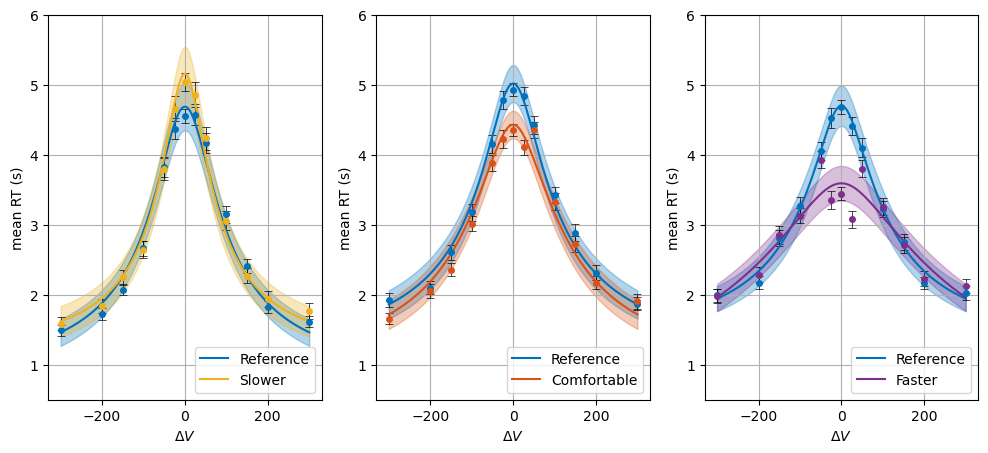

In [5]:
from scipy import stats

fig1 = plt.figure(figsize=(12, 5))
colorRef = [0,0.4470,0.7410]

# Loop through chunks of 26
for i in range(0, 78, 26):    
    chunk_RT = y_RT[i:i+26]       
        
    ref_RT = np.mean(chunk_RT[::2],axis=0)  # Even indices: 0, 2, 4, ...
    test_RT = np.mean(chunk_RT[1::2],axis=0)  # Odd indices: 1, 3, 5, ...
    # Calculate standard errors for fitted curves
    ref_RT_se = stats.sem(chunk_RT[::2], axis=0)  # Standard error of the mean
    test_RT_se = stats.sem(chunk_RT[1::2], axis=0)

    if i == 0: # Comfortable group
        # Calculate the mean for the scatter plots
        refmean_RT = df_excludingNR[(df_excludingNR['subID'] < 14) & (df_excludingNR['speed'] == 0)].groupby([stimuli])['reactionTime'].mean()
        testmean_RT = df_excludingNR[(df_excludingNR['subID'] < 14) & (df_excludingNR['speed'] == 2)].groupby([stimuli])['reactionTime'].mean()
        dv_ref = refmean_RT.index.to_numpy()
        dv_test = testmean_RT.index.to_numpy()
        # Calculate standard errors for scatter points
        refse_RT = df_excludingNR[(df_excludingNR['subID'] < 14) & (df_excludingNR['speed'] == 0)].groupby([stimuli])['reactionTime'].sem()
        testse_RT = df_excludingNR[(df_excludingNR['subID'] < 14) & (df_excludingNR['speed'] == 2)].groupby([stimuli])['reactionTime'].sem()
        # Actual plotting
        colorTest = [0.85,0.325,0.098]
        plt.subplot(1, 3, 2)
        # Plot with error bars
        plt.errorbar(dv_ref,refmean_RT,yerr=refse_RT,fmt='o',markersize=4,color=colorRef,capsize=3,capthick=0.5,ecolor='black',elinewidth=0.5)
        plt.errorbar(dv_test,testmean_RT,yerr=testse_RT,fmt='o',markersize=4,color=colorTest,capsize=3,capthick=0.5,ecolor='black',elinewidth=0.5)
        # Plot fitted lines with error bands
        plt.fill_between(aux,ref_RT-ref_RT_se,ref_RT+ref_RT_se,color=colorRef,alpha=0.3)
        plt.fill_between(aux,test_RT-test_RT_se,test_RT+test_RT_se,color=colorTest,alpha=0.3)
        plt.plot(aux, ref_RT, color=colorRef, label='Reference')
        plt.plot(aux, test_RT, color=colorTest, label='Comfortable')
        plt.ylim((0.5,6))
        plt.legend(loc='lower right')
        plt.grid()
        plt.ylabel('mean RT (s)')
        if stimuli == 'pertSize':
            plt.xlabel(r'$\Delta V$')
        else:
            plt.xlabel(r'$\frac{\Delta V}{\bar{V}}$')

        
    elif i == 26: # Slower group        
        plt.subplot(1, 3, 1)
        # Calculate the mean for the scatter plots
        refmean_RT = df_excludingNR[(df_excludingNR['subID'] > 13) & (df_excludingNR['subID'] < 27) & (df_excludingNR['speed'] == 0)].groupby([stimuli])['reactionTime'].mean()
        testmean_RT = df_excludingNR[(df_excludingNR['subID'] > 13) & (df_excludingNR['subID'] < 27) & (df_excludingNR['speed'] == 1)].groupby([stimuli])['reactionTime'].mean()
        dv_ref = refmean_RT.index.to_numpy()
        dv_test = testmean_RT.index.to_numpy()
        # Calculate standard errors for scatter points
        refse_RT = df_excludingNR[(df_excludingNR['subID'] > 13) & (df_excludingNR['subID'] < 27) & (df_excludingNR['speed'] == 0)].groupby([stimuli])['reactionTime'].sem()
        testse_RT = df_excludingNR[(df_excludingNR['subID'] > 13) & (df_excludingNR['subID'] < 27) & (df_excludingNR['speed'] == 1)].groupby([stimuli])['reactionTime'].sem()
        # Actual plotting
        colorTest = [0.9290,0.6940,0.1250]
        # Plot with error bars
        plt.errorbar(dv_ref,refmean_RT,yerr=refse_RT,fmt='o',markersize=4,color=colorRef,capsize=3,capthick=0.5,ecolor='black',elinewidth=0.5)
        plt.errorbar(dv_test,testmean_RT,yerr=testse_RT,fmt='o',markersize=4,color=colorTest,capsize=3,capthick=0.5,ecolor='black',elinewidth=0.5)       
        # Plot fitted lines with error bands
        plt.fill_between(aux,ref_RT-ref_RT_se,ref_RT+ref_RT_se,color=colorRef,alpha=0.3)
        plt.fill_between(aux,test_RT-test_RT_se,test_RT+test_RT_se,color=colorTest,alpha=0.3)
        plt.plot(aux, ref_RT, color=colorRef, label='Reference')
        plt.plot(aux, test_RT, color=colorTest, label='Slower')
        plt.ylim((0.5,6))
        plt.legend(loc='lower right')
        plt.grid()
        plt.ylabel('mean RT (s)')
        if stimuli == 'pertSize':
            plt.xlabel(r'$\Delta V$')
        else:
            plt.xlabel(r'$\frac{\Delta V}{\bar{V}}$')

        
    elif i == 52: # Faster group
        plt.subplot(1, 3, 3)
        # Calculate the mean for the scatter plots
        refmean_RT = df_excludingNR[(df_excludingNR['subID'] > 26) & (df_excludingNR['speed'] == 0)].groupby([stimuli])['reactionTime'].mean()
        testmean_RT = df_excludingNR[(df_excludingNR['subID'] > 26) & (df_excludingNR['speed'] == 3)].groupby([stimuli])['reactionTime'].mean()
        dv_ref = refmean_RT.index.to_numpy()
        dv_test = testmean_RT.index.to_numpy()
        # Calculate standard errors for scatter points
        refse_RT = df_excludingNR[(df_excludingNR['subID'] > 26) & (df_excludingNR['speed'] == 0)].groupby([stimuli])['reactionTime'].sem()
        testse_RT = df_excludingNR[(df_excludingNR['subID'] > 26) & (df_excludingNR['speed'] == 3)].groupby([stimuli])['reactionTime'].sem()
        # Actual plotting
        colorTest = [0.494,0.184,0.556]
        # Plot with error bars
        plt.errorbar(dv_ref,refmean_RT,yerr=refse_RT,fmt='o',markersize=4,color=colorRef,capsize=3,capthick=0.5,ecolor='black',elinewidth=0.5)
        plt.errorbar(dv_test,testmean_RT,yerr=testse_RT,fmt='o',markersize=4,color=colorTest,capsize=3,capthick=0.5,ecolor='black',elinewidth=0.5)       
        # Plot fitted lines with error bands
        plt.fill_between(aux,ref_RT-ref_RT_se,ref_RT+ref_RT_se,color=colorRef,alpha=0.3)
        plt.fill_between(aux,test_RT-test_RT_se,test_RT+test_RT_se,color=colorTest,alpha=0.3)
        plt.plot(aux, ref_RT, color=colorRef, label='Reference')
        plt.plot(aux, test_RT, color=colorTest, label='Faster')
        plt.ylim((0.5,6))
        plt.legend(loc='lower right')
        plt.grid()
        plt.ylabel('mean RT (s)')
        if stimuli == 'pertSize':
            plt.xlabel(r'$\Delta V$')
        else:
            plt.xlabel(r'$\frac{\Delta V}{\bar{V}}$')

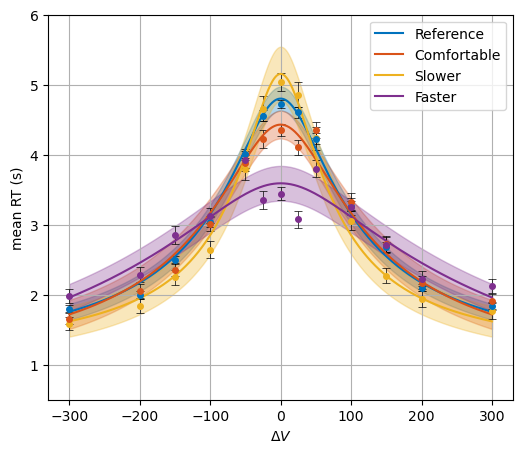

In [6]:
# Now do the same but pooling all the reference data

from scipy import stats

fig1 = plt.figure(figsize=(6, 5))

# Calculate the mean for the scatter plots
refmean_RT = df_excludingNR[(df_excludingNR['speed'] == 0)].groupby([stimuli])['reactionTime'].mean()
comfortableMean_RT = df_excludingNR[(df_excludingNR['speed'] == 2)].groupby([stimuli])['reactionTime'].mean()
slowerMean_RT = df_excludingNR[(df_excludingNR['speed'] == 1)].groupby([stimuli])['reactionTime'].mean()
fasterMean_RT = df_excludingNR[(df_excludingNR['speed'] == 3)].groupby([stimuli])['reactionTime'].mean()

# Calculate standard errors for fitted curves
refmean_RT_se = df_excludingNR[(df_excludingNR['speed'] == 0)].groupby([stimuli])['reactionTime'].sem()  # Standard error of the mean
comfortableMean_RT_se = df_excludingNR[(df_excludingNR['speed'] == 2)].groupby([stimuli])['reactionTime'].sem()
slowerMean_RT_se = df_excludingNR[(df_excludingNR['speed'] == 1)].groupby([stimuli])['reactionTime'].sem()
fasterMean_RT_se = df_excludingNR[(df_excludingNR['speed'] == 3)].groupby([stimuli])['reactionTime'].sem()

# Plot the data (scatter)
colorTest = [0.85,0.325,0.098]
plt.errorbar(slowerMean_RT.index.to_numpy(),slowerMean_RT,yerr=slowerMean_RT_se,fmt='o',markersize=4,color=[0.9290,0.6940,0.1250],capsize=3,capthick=0.5,ecolor='black',elinewidth=0.5)
plt.errorbar(refmean_RT.index.to_numpy(),refmean_RT,yerr=refmean_RT_se,fmt='o',markersize=4,color=[0,0.4470,0.7410],capsize=3,capthick=0.5,ecolor='black',elinewidth=0.5)
plt.errorbar(comfortableMean_RT.index.to_numpy(),comfortableMean_RT,yerr=comfortableMean_RT_se,fmt='o',markersize=4,color=[0.85,0.325,0.098],capsize=3,capthick=0.5,ecolor='black',elinewidth=0.5)
plt.errorbar(fasterMean_RT.index.to_numpy(),fasterMean_RT,yerr=fasterMean_RT_se,fmt='o',markersize=4,color=[0.494,0.184,0.556],capsize=3,capthick=0.5,ecolor='black',elinewidth=0.5)

# Plot the fitted lines for the reference speed reaction times
ref_RT = np.mean(y_RT[::2],axis=0)  # Even indices: 0, 2, 4, ...
ref_RT_se = stats.sem(y_RT[::2], axis=0)  # Standard error of the mean
plt.fill_between(aux,ref_RT-ref_RT_se,ref_RT+ref_RT_se,color=[0,0.4470,0.7410],alpha=0.3)
plt.plot(aux,ref_RT,color=[0,0.4470,0.7410], label='Reference')

# Loop through chunks of 26
for i in range(0, 78, 26):    
    chunk_RT = y_RT[i:i+26]          
    test_RT = np.mean(chunk_RT[1::2],axis=0)  # Odd indices: 1, 3, 5, ...
    # Calculate standard errors for fitted curves   
    test_RT_se = stats.sem(chunk_RT[1::2], axis=0)

    if i == 0: # Comfortable group
        # Plot fitted lines with error bands       
        plt.fill_between(aux,test_RT-test_RT_se,test_RT+test_RT_se,color=[0.85,0.325,0.098],alpha=0.3)        
        plt.plot(aux, test_RT, color=[0.85,0.325,0.098], label='Comfortable')
            
    elif i == 26: # Slower group       
        # Plot fitted lines with error bands
        plt.fill_between(aux,test_RT-test_RT_se,test_RT+test_RT_se,color=[0.9290,0.6940,0.1250],alpha=0.3)
        plt.plot(aux, test_RT, color=[0.9290,0.6940,0.1250], label='Slower')
                
    elif i == 52: # Faster group        
        # Plot fitted lines with error bands
        plt.fill_between(aux,test_RT-test_RT_se,test_RT+test_RT_se,color=[0.494,0.184,0.556],alpha=0.3)
        plt.plot(aux, test_RT, color=[0.494,0.184,0.556], label='Faster')
        

plt.ylim((0.5,6))
plt.legend(loc='upper right')
plt.ylabel('mean RT (s)')
if stimuli == 'pertSize':
    plt.xlabel(r'$\Delta V$')
else:
    plt.xlabel(r'$\frac{\Delta V}{\bar{V}}$')
plt.grid()

# plt.savefig('RTplotsPertSize.eps', format='eps')